In [1]:
from google.colab import drive
drive.mount('/content/drive')




Mounted at /content/drive


In [2]:
# Practice Q.1
import pandas as pd
penguin_data = pd.read_csv("/content/drive/MyDrive/penguins_size.csv")
penguin_data


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,FEMALE
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,MALE
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,FEMALE


In [3]:
rows = penguin_data.iloc[0:10]
print(rows)

  species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen              39.1             18.7              181.0   
1  Adelie  Torgersen              39.5             17.4              186.0   
2  Adelie  Torgersen              40.3             18.0              195.0   
3  Adelie  Torgersen               NaN              NaN                NaN   
4  Adelie  Torgersen              36.7             19.3              193.0   
5  Adelie  Torgersen              39.3             20.6              190.0   
6  Adelie  Torgersen              38.9             17.8              181.0   
7  Adelie  Torgersen              39.2             19.6              195.0   
8  Adelie  Torgersen              34.1             18.1              193.0   
9  Adelie  Torgersen              42.0             20.2              190.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  

In [4]:
# Practice Q.2
from sklearn.model_selection import train_test_split
X = penguin_data.drop(columns=['sex'])
y = penguin_data['sex']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state= 42)
print (X_train,y_train)
print (X_test,y_test)


       species     island  culmen_length_mm  culmen_depth_mm  \
66      Adelie     Biscoe              35.5             16.2   
229     Gentoo     Biscoe              46.8             15.4   
7       Adelie  Torgersen              39.2             19.6   
140     Adelie      Dream              40.2             17.1   
323     Gentoo     Biscoe              49.1             15.0   
..         ...        ...               ...              ...   
188  Chinstrap      Dream              47.6             18.3   
71      Adelie  Torgersen              39.7             18.4   
106     Adelie     Biscoe              38.6             17.2   
270     Gentoo     Biscoe              46.6             14.2   
102     Adelie     Biscoe              37.7             16.0   

     flipper_length_mm  body_mass_g  
66               195.0       3350.0  
229              215.0       5150.0  
7                195.0       4675.0  
140              193.0       3400.0  
323              228.0       5500.0  
.. 

In [6]:
# Practice Q.3
import pandas as pd
house_sales = pd.read_csv("/content/drive/MyDrive/kc_house_data.csv")
house_sales.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:

X = house_sales[['sqft_living']]
y = house_sales['price']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

from sklearn import linear_model

model = linear_model.LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Checking Accuracy (Regression evaluation metrics)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)

print(f"Mean absolute error is: {mae:.2f}\nMean squared error is: {mse:.2f}\nRoot mean squared error is: {rmse:.2f}\nCoefficient of determination is: {r2:.2f}")

# 49% of variance in the house prices can be explained by the model.






Mean absolute error is: 177867.54
Mean squared error is: 76484977061.78
Root mean squared error is: 276559.17
Coefficient of determination is: 0.49


In [8]:
area_input = 2000
predicted_price = model.predict(pd.DataFrame([[area_input]], columns=['sqft_living']))
print(f"Predicted price is: {predicted_price[0]:.2f}")

Predicted price is: 517110.37


In [9]:
from google.colab import files
uploaded = files.upload()
import io

Saving penguins_size.csv to penguins_size.csv


In [10]:
# Assignment 1
import pandas as pd
penguins = pd.read_csv(io.BytesIO(uploaded['penguins_size.csv']))
penguins_original = penguins.copy()
penguins.info()
penguins.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [13]:
# Assignment 2

numerical_cols = penguins.select_dtypes(include='number').columns
penguins[numerical_cols].isnull().sum()

print(f"The skew is:\n{penguins[numerical_cols].skew()}")
# mean and median values are not far apart in the table and skew lies between -0.5 and 0.5
# thus, data seems to be approximately symmetric, hence mean imputation will be used

penguins[numerical_cols] = penguins[numerical_cols].fillna(penguins[numerical_cols].mean())

penguins[numerical_cols].isnull().sum()








The skew is:
culmen_length_mm     0.053272
culmen_depth_mm     -0.143880
flipper_length_mm    0.346682
body_mass_g          0.471690
dtype: float64


,0
culmen_length_mm,0
culmen_depth_mm,0
flipper_length_mm,0
body_mass_g,0


In [14]:
# Assignment Q.3

# Before starting, we have to check and replace any non-null junk values that are present:

categorical_cols = penguins.select_dtypes(include=['object']).columns

for col in categorical_cols:
  print(f"Initial value counts:\n{penguins[col].value_counts()}")
  print('\n')

import numpy as np
penguins['sex']= penguins['sex'].replace('.', np.nan)

print(f"Updated sex value counts:\n{penguins['sex'].value_counts()}")
print(f"Actual null values:\n{penguins[categorical_cols].isnull().sum()}")

#Imputing the null values:

penguins['sex'] = penguins['sex'].fillna(penguins['sex'].mode()[0])

print(f"Null values after imputation:\n{penguins[categorical_cols].isnull().sum()}")

# Using LabelEncoder for sex column(ordinal):

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
penguins['sex'] = le.fit_transform(penguins['sex'])

# Usng OneHotEncoder for species and island columns(nominal):

from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False,drop='first')
encoded_array = ohe.fit_transform(penguins[['island', 'species']])
encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(['island', 'species']))

penguins = pd.concat([penguins.drop(columns=['island', 'species']).reset_index(drop=True),encoded_df],axis =1)

print(penguins_original)

print(penguins)





Initial value counts:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


Initial value counts:
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64


Initial value counts:
sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64


Updated sex value counts:
sex
MALE      168
FEMALE    165
Name: count, dtype: int64
Actual null values:
species     0
island      0
sex        11
dtype: int64
Null values after imputation:
species    0
island     0
sex        0
dtype: int64
    species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0    Adelie  Torgersen              39.1             18.7              181.0   
1    Adelie  Torgersen              39.5             17.4              186.0   
2    Adelie  Torgersen              40.3             18.0              195.0   
3    Adelie  Torgersen               NaN              NaN                NaN   
4    Adelie  Torgersen              36.7      

In [15]:
# Mini- Project:
from google.colab import files
import io
uploaded= files.upload()

Saving Titanic-Dataset.csv to Titanic-Dataset.csv


In [16]:
import pandas as pd
titanic= pd.read_csv('Titanic-Dataset.csv')
titanic_original = titanic.copy()
titanic.info()
titanic.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [19]:
# Task 1:

# Cleaning missing numerical data:

print(f"The skew is:  {titanic['Age'].skew()}") #Looking at skew,mean and median; mean imputation seems best.
titanic['Age'] = titanic['Age'].fillna(titanic['Age'].mean())
print(f"Final null values for Age:\n{titanic['Age'].isnull().sum()}")

# Cleaning missing categorical data:

# For the column 'Cabin',since over 70% of the values are null, imputing would result with almost fully made-up data.
# Hence, it is best to simply label those values as missing.Doing so will also not affect the rest of the project negatively.

titanic['Cabin']= titanic['Cabin'].fillna('Missing')
print(f"Final null values for Cabin:\n{titanic['Cabin'].isnull().sum()}")

# For the column Embarked, mode imputation seems best as relatively few values are missing
titanic['Embarked']= titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
print(f"Final null values for Embarked:\n{titanic['Embarked'].isnull().sum()}")

# In columns with limited categories we can check for any missing/junk categories that appear as non-null:
for col in ['Survived', 'Pclass', 'Sex', 'SibSp', 'Parch','Embarked']:
  print(titanic[col].value_counts())
  print('\n')





The skew is:  0.4344880940129925
Final null values for Age:
0
Final null values for Cabin:
0
Final null values for Embarked:
0
Survived
0    549
1    342
Name: count, dtype: int64


Pclass
3    491
1    216
2    184
Name: count, dtype: int64


Sex
male      577
female    314
Name: count, dtype: int64


SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64


Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64


Embarked
S    646
C    168
Q     77
Name: count, dtype: int64




In [20]:
# Task 2:

from sklearn.preprocessing import LabelEncoder
le_sex = LabelEncoder()
titanic['Sex'] = le_sex.fit_transform(titanic['Sex'])

from sklearn.preprocessing import OneHotEncoder
ohe_em = OneHotEncoder(sparse_output=False, drop= 'first')
encoded_array_em = ohe_em.fit_transform(titanic[['Embarked']])
encoded_df_em = pd.DataFrame(encoded_array_em, columns=ohe_em.get_feature_names_out(['Embarked']))

titanic = pd.concat([titanic.drop(columns=['Embarked']).reset_index(drop=True),encoded_df_em], axis=1)

print(dict(enumerate(le_sex.classes_)))

print(titanic_original.head())

print(titanic.head())







{0: 'female', 1: 'male'}
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

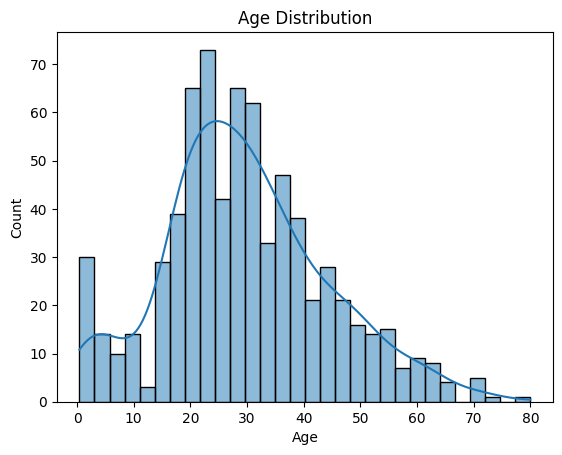

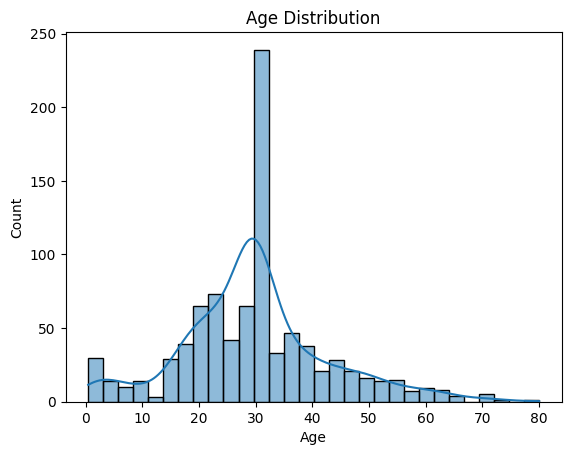

In [21]:
# Task 3:

import matplotlib.pyplot as plt
import seaborn as sns

# Original data:
sns.histplot(titanic_original['Age'], kde=True, bins=30)
plt.title('Age Distribution')
plt.show()

# After data processing done in previous steps:
sns.histplot(titanic['Age'], kde=True, bins=30)
plt.title('Age Distribution')
plt.show()




In [22]:
# Task 4:

titanic.to_csv('cleaned_titanic.csv', index=False)